In [27]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import acf , pacf
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime,timedelta


In [28]:
register_matplotlib_converters()

<h2> Generate Some Data </h2>


$$
\huge{y=50+0.4*\varepsilon_{t-1}+0.3*\varepsilon_{t-2}+\varepsilon_{t}} 
$$

$$
\huge{\varepsilon_{t} \sim N(0, 1)}
$$

In [29]:
erros=np.random.normal(0,1,400)
erros[:5]

array([ 0.22177151,  1.52270328, -0.10543422, -0.53162402,  1.64558679])

In [30]:
date_index=pd.date_range(start="9/1/2019",end="1/1/2020")
date_index[:5]

DatetimeIndex(['2019-09-01', '2019-09-02', '2019-09-03', '2019-09-04',
               '2019-09-05'],
              dtype='datetime64[ns]', freq='D')

In [31]:
mu=50
series=[]
for t in range(1,len(date_index)+1):
    series.append(mu+0.4*erros[t-1]+0.3*erros[t-2]+erros[t])

In [32]:
series=pd.Series(series,date_index)
series=series.asfreq(pd.infer_freq(series.index))
series[:5]

2019-09-01    51.625185
2019-09-02    50.570179
2019-09-03    49.883013
2019-09-04    51.401307
2019-09-05    50.429601
Freq: D, dtype: float64

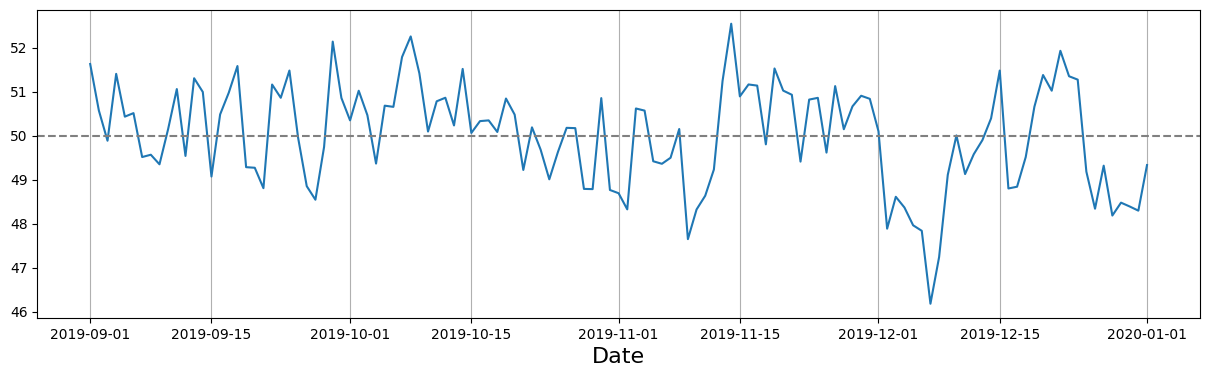

In [33]:
plt.figure(figsize=(15,4))
plt.plot(series)
plt.xlabel("Date",fontsize=16)
plt.axhline(mu,linestyle="--",color="grey")
plt.grid(axis="x")
plt.show()

<h2> ACF</h2>

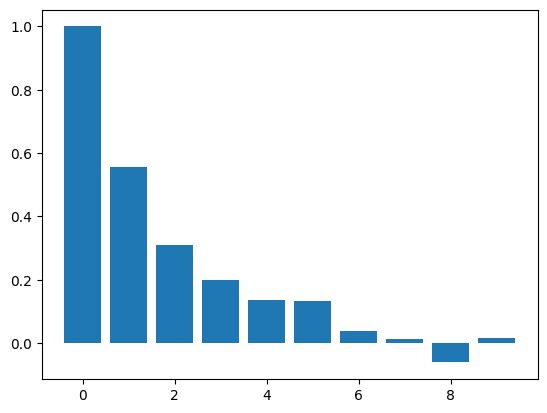

In [34]:
acf_vals=acf(series)
num_lags=10
plt.bar(range(num_lags),acf_vals[:num_lags])
plt.show()

<h1> PACF </h2>

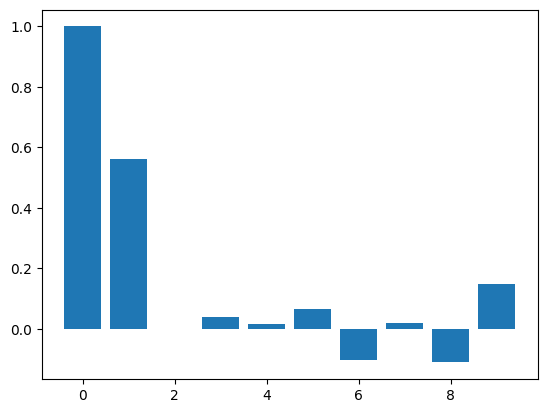

In [35]:
pacf_vals=pacf(series)
num_lags=10
plt.bar(range(num_lags),pacf_vals[:num_lags])
plt.show()

<h2> Get training and testing sets </h2>

In [36]:
train_end=datetime(2019,12,30)
test_end=datetime(2020,1,1)
train_data=series[:train_end]
test_data=series[train_end+timedelta(days=1):test_end]

<h2>Fit Arima Model </h2>

In [ ]:
model=ARIMA(train_data,order=(0,0,2))

In [ ]:
model_fit=model.fit()

In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  121
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -169.089
Date:                Sat, 15 Mar 2025   AIC                            346.179
Time:                        03:19:24   BIC                            357.362
Sample:                    09-01-2019   HQIC                           350.721
                         - 12-30-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.0298      0.159    315.249      0.000      49.719      50.341
ma.L1          0.5405      0.100      5.400      0.000       0.344       0.737
ma.L2          0.2378      0.102      2.321      0.0

<h2> predicted value </h2>

$$
\huge{\hat{t}_t =50+0.37*\varepsilon_{t-1}+0.25*\varepsilon_{t-2}+\varepsilon_{t}}
$$

In [ ]:
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print("pred_start_date:",pred_start_date)
print("pred_end_date:",pred_end_date)

pred_start_date: 2019-12-31 00:00:00
pred_end_date: 2020-01-01 00:00:00


In [ ]:
predictions=model_fit.predict(start=pred_start_date,end=pred_end_date)
predictions[:5]

2019-12-31    49.398106
2020-01-01    49.824120
Freq: D, Name: predicted_mean, dtype: float64

In [42]:
residuals=test_data-predictions

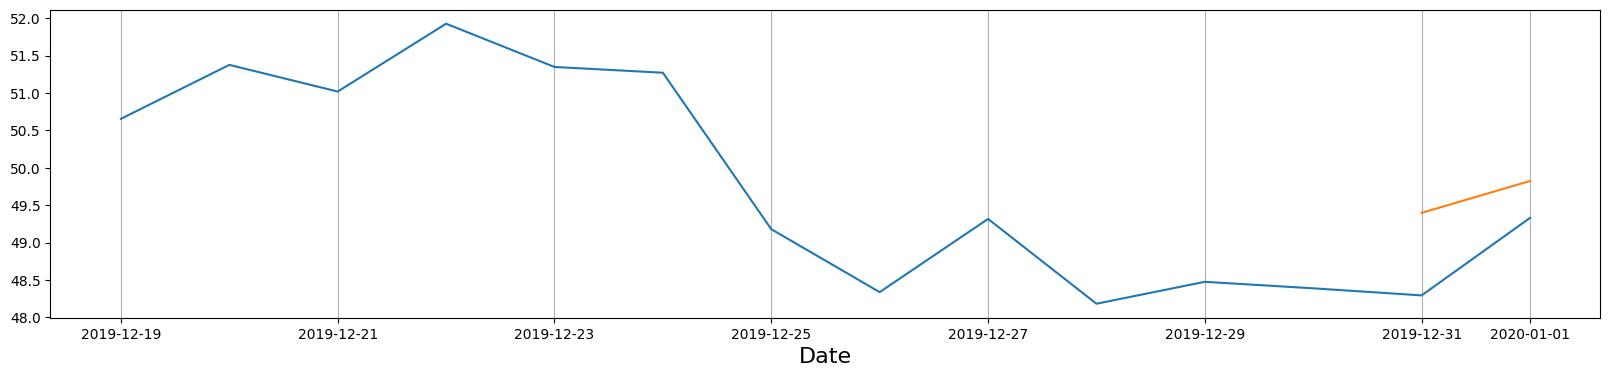

In [47]:
plt.figure(figsize=(20,4))
plt.plot(series[-14:])
plt.plot(predictions)
plt.xlabel("Date",fontsize=16)
plt.grid(axis="x")
plt.show()

In [44]:
print("Mean Absolute Percent Error:",round(np.mean(abs(residuals/test_data)),4))

Mean Absolute Percent Error: 0.0164


In [45]:
print("Root Mean Sqaured Error:",np.sqrt(np.mean(residuals**2)))

Root Mean Sqaured Error: 0.8545706432409453
